# 서울시 자치구별 미세먼지(PM-2.5) 격차 분석

**분석 목적**: 서울시 25개 자치구의 녹지·공원 현황이 초미세먼지(PM-2.5) 농도에 미치는 영향을 가설검정과 회귀분석으로 규명한다.

**데이터 출처**
- 서울시 대기오염(구별) 통계 — 서울 열린데이터광장
- 서울시 녹지현황 통계 — 서울 열린데이터광장
- 서울시 공원(공원율) 통계 — 서울 열린데이터광장

**가설**
- H1: 녹지 면적이 많은 자치구일수록 PM-2.5 연평균이 낮다 (독립표본 t-test)
- H2: 계절(봄/여름/가을/겨울)에 따라 PM-2.5 평균에 유의한 차이가 있다 (one-way ANOVA)
- H3: 2019~2024년 기간 동안 서울시 전체 PM-2.5가 유의하게 감소했다 (추세 회귀 검정)

**설치 필요 패키지**
```
pip install scipy statsmodels seaborn
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 전처리

In [2]:
# ── 1-1. 미세먼지 데이터 (dust.csv) ──────────────────────────────
df_dust_raw = pd.read_csv('data/dust.csv', encoding='utf-8-sig', engine='python', on_bad_lines='skip')

# PM-2.5만 필터, 서울 평균(평 균) 제외
df_pm25 = df_dust_raw[
    (df_dust_raw['항목'] == '초미세먼지(PM-2.5)') &
    (~df_dust_raw['구분별'].str.strip().isin(['평 균']))
].copy()

df_pm25 = df_pm25.rename(columns={'구분별': '자치구'})
df_pm25['자치구'] = df_pm25['자치구'].str.strip()

# wide → long 변환
date_cols = [c for c in df_pm25.columns if '월' in str(c)]
df_pm25_long = df_pm25.melt(
    id_vars=['자치구'],
    value_vars=date_cols,
    var_name='연월',
    value_name='PM25'
)

# 연월 파싱
df_pm25_long['연도'] = df_pm25_long['연월'].str.extract(r'(\d{4})').astype(int)
df_pm25_long['월'] = df_pm25_long['연월'].str.extract(r'\d{4}\. (\d{2})').astype(int)
df_pm25_long['PM25'] = pd.to_numeric(df_pm25_long['PM25'], errors='coerce')
df_pm25_long = df_pm25_long.dropna(subset=['PM25'])

# 계절 구분
def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in [9, 10, 11]: return '가을'
    else: return '겨울'

df_pm25_long['계절'] = df_pm25_long['월'].apply(get_season)

print('dust 전처리 완료:', df_pm25_long.shape)
print(df_pm25_long.head())

dust 전처리 완료: (2978, 6)
   자치구          연월  PM25    연도  월  계절
0  종로구  2015. 01 월  24.0  2015  1  겨울
1   중구  2015. 01 월  21.0  2015  1  겨울
2  용산구  2015. 01 월  23.0  2015  1  겨울
3  성동구  2015. 01 월  28.0  2015  1  겨울
4  광진구  2015. 01 월  24.0  2015  1  겨울


In [3]:
# ── 1-2. 녹지 데이터 (green.csv) ──────────────────────────────
df_green_raw = pd.read_csv('data/green.csv', encoding='utf-8-sig', engine='python',
                           on_bad_lines='skip', header=None)

# 헤더 3행: row0=연도, row1=항목대분류, row2=단위
# 합계 면적만 추출 (col 인덱스 파악)
years_row = df_green_raw.iloc[0].tolist()
items_row = df_green_raw.iloc[1].tolist()
units_row = df_green_raw.iloc[2].tolist()

# 구 이름: col 1 (구분별(2))
# 합계 면적 (㎡): 각 연도 첫 번째 '합계' + '면적 (㎡)' 컬럼
green_records = []
data_rows = df_green_raw.iloc[3:].copy()

# 연도별 합계 면적 컬럼 찾기
target_cols = {}
for i, (yr, item, unit) in enumerate(zip(years_row, items_row, units_row)):
    if str(yr).isdigit() and str(item) == '합계' and '면적' in str(unit):
        if yr not in target_cols:  # 연도당 첫 번째 합계 면적만
            target_cols[int(yr)] = i

# 서울시 제외, 자치구만
gu_col = 1
exclude = ['소계', '구분별(2)', '서울시', float('nan')]

for _, row in data_rows.iterrows():
    gu = str(row.iloc[gu_col]).strip()
    if gu in exclude or pd.isna(row.iloc[gu_col]):
        continue
    if not gu.endswith('구'):
        continue
    for yr, col_idx in target_cols.items():
        val = pd.to_numeric(row.iloc[col_idx], errors='coerce')
        green_records.append({'자치구': gu, '연도': yr, '녹지면적_m2': val})

df_green = pd.DataFrame(green_records).dropna()
print('green 전처리 완료:', df_green.shape)
print(df_green.head(10))

green 전처리 완료: (250, 3)
   자치구    연도  녹지면적_m2
0  종로구  2015   240176
1  종로구  2016   221254
2  종로구  2017   222225
3  종로구  2018   225201
4  종로구  2019   218331
5  종로구  2020   218475
6  종로구  2021   224004
7  종로구  2022   228451
8  종로구  2023   228451
9  종로구  2024   228568


In [4]:
# ── 1-3. 공원 데이터 (park.csv) ──────────────────────────────
df_park_raw = pd.read_csv('data/park.csv', encoding='utf-8-sig', engine='python',
                          on_bad_lines='skip', header=None)

years_row_p = df_park_raw.iloc[0].tolist()
items_row_p = df_park_raw.iloc[1].tolist()
units_row_p = df_park_raw.iloc[2].tolist()

# 공원율(%) 컬럼 찾기
park_cols = {}
for i, (yr, item, unit) in enumerate(zip(years_row_p, items_row_p, units_row_p)):
    if str(yr).isdigit() and '공원율' in str(unit):
        yr_int = int(yr)
        if yr_int not in park_cols:
            park_cols[yr_int] = i

park_records = []
data_rows_p = df_park_raw.iloc[3:].copy()

for _, row in data_rows_p.iterrows():
    gu = str(row.iloc[1]).strip()
    if not gu.endswith('구'):
        continue
    for yr, col_idx in park_cols.items():
        val = pd.to_numeric(row.iloc[col_idx], errors='coerce')
        park_records.append({'자치구': gu, '연도': yr, '공원율': val})

df_park = pd.DataFrame(park_records).dropna()
print('park 전처리 완료:', df_park.shape)
print(df_park.head(10))

park 전처리 완료: (250, 3)
   자치구    연도    공원율
0  종로구  2015  48.41
1  종로구  2016  48.37
2  종로구  2017  48.38
3  종로구  2018  48.32
4  종로구  2019  48.33
5  종로구  2020  47.68
6  종로구  2021  47.69
7  종로구  2022  47.82
8  종로구  2023  47.82
9  종로구  2024  47.87


In [5]:
# ── 1-4. 분석용 통합 데이터셋 (연간 평균 PM-2.5 + 녹지 + 공원) ──
# 2019~2024 기준 (녹지·공원 데이터와 겹치는 기간)
df_annual_pm25 = (
    df_pm25_long[df_pm25_long['연도'].between(2019, 2024)]
    .groupby(['자치구', '연도'])['PM25']
    .mean()
    .reset_index()
    .rename(columns={'PM25': 'PM25_연평균'})
)

df_merged = (
    df_annual_pm25
    .merge(df_green, on=['자치구', '연도'], how='left')
    .merge(df_park,  on=['자치구', '연도'], how='left')
)

# 녹지면적 → km²
df_merged['녹지면적_km2'] = df_merged['녹지면적_m2'] / 1_000_000

print('통합 데이터 shape:', df_merged.shape)
print(df_merged.head())
print('\n결측치:\n', df_merged.isnull().sum())

통합 데이터 shape: (150, 6)
   자치구    연도   PM25_연평균  녹지면적_m2    공원율  녹지면적_km2
0  강남구  2019  26.000000  1566004  16.69  1.566004
1  강남구  2020  21.166667  1589048  19.67  1.589048
2  강남구  2021  20.083333  2007604  19.73  2.007604
3  강남구  2022  17.666667  2002550  19.73  2.002550
4  강남구  2023  19.500000  1950588  19.73  1.950588

결측치:
 자치구         0
연도          0
PM25_연평균    0
녹지면적_m2     0
공원율         0
녹지면적_km2    0
dtype: int64


## 2. 탐색적 데이터 분석 (EDA)

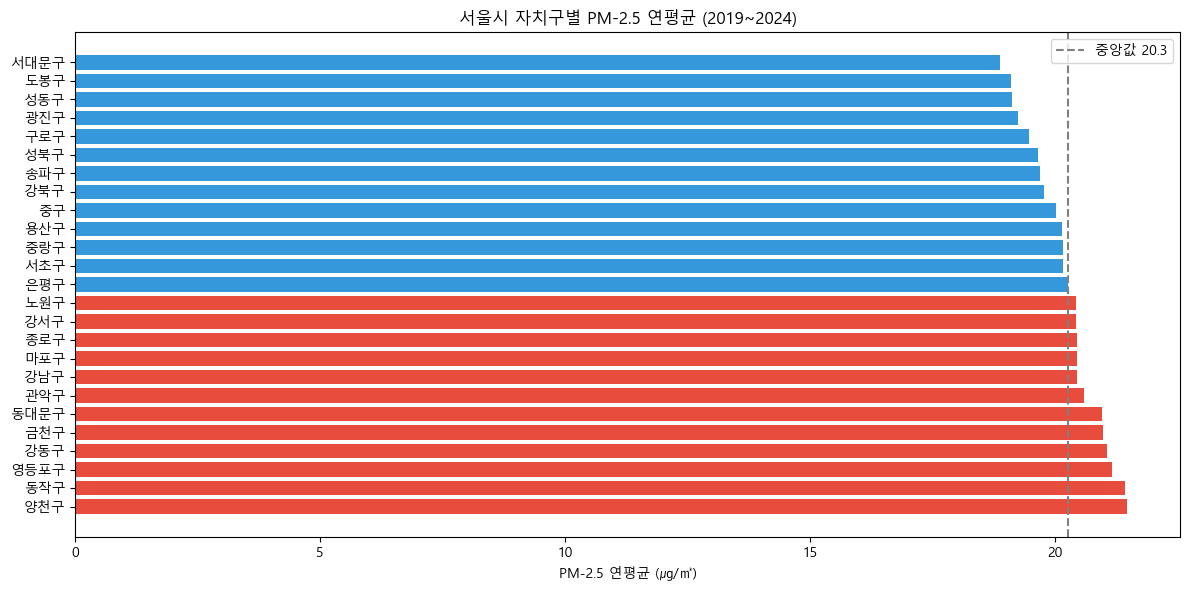


상위 5 (고농도): {'양천구': 21.48611111111111, '동작구': 21.444444444444443, '영등포구': 21.180555555555554, '강동구': 21.06313131313131, '금천구': 20.98611111111111}
하위 5 (저농도): {'구로구': 19.48611111111111, '광진구': 19.25, '성동구': 19.125, '도봉구': 19.119444444444444, '서대문구': 18.875}


In [6]:
# 자치구별 PM-2.5 연평균 (2019~2024)
gu_avg = (
    df_merged.groupby('자치구')['PM25_연평균']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > gu_avg.median() else '#3498db' for v in gu_avg.values]
ax.barh(gu_avg.index, gu_avg.values, color=colors)
ax.axvline(gu_avg.median(), color='gray', linestyle='--', label=f'중앙값 {gu_avg.median():.1f}')
ax.set_xlabel('PM-2.5 연평균 (㎍/㎥)')
ax.set_title('서울시 자치구별 PM-2.5 연평균 (2019~2024)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_gu_pm25.png', dpi=150)
plt.show()

print('\n상위 5 (고농도):', gu_avg.head().to_dict())
print('하위 5 (저농도):', gu_avg.tail().to_dict())

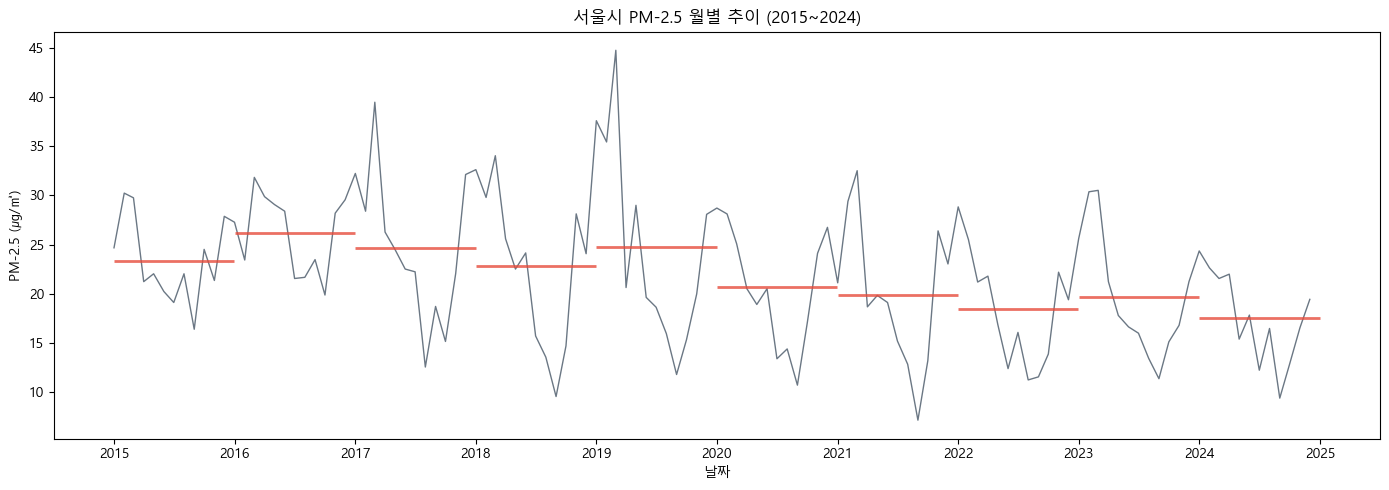

In [7]:
# 서울 전체 월별 PM-2.5 추이 (2015~2024)
monthly_avg = (
    df_pm25_long
    .groupby(['연도', '월'])['PM25']
    .mean()
    .reset_index()
)
monthly_avg['날짜'] = pd.to_datetime(
    monthly_avg['연도'].astype(str) + '-' + monthly_avg['월'].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_avg['날짜'], monthly_avg['PM25'], linewidth=1, alpha=0.7, color='#2c3e50')

# 연간 평균 오버레이
annual_avg = monthly_avg.groupby('연도')['PM25'].mean()
for yr, val in annual_avg.items():
    ax.hlines(val, pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr}-12-31'),
              colors='#e74c3c', linewidth=2, alpha=0.8)

ax.set_xlabel('날짜')
ax.set_ylabel('PM-2.5 (㎍/㎥)')
ax.set_title('서울시 PM-2.5 월별 추이 (2015~2024)')
plt.tight_layout()
plt.savefig('eda_trend.png', dpi=150)
plt.show()

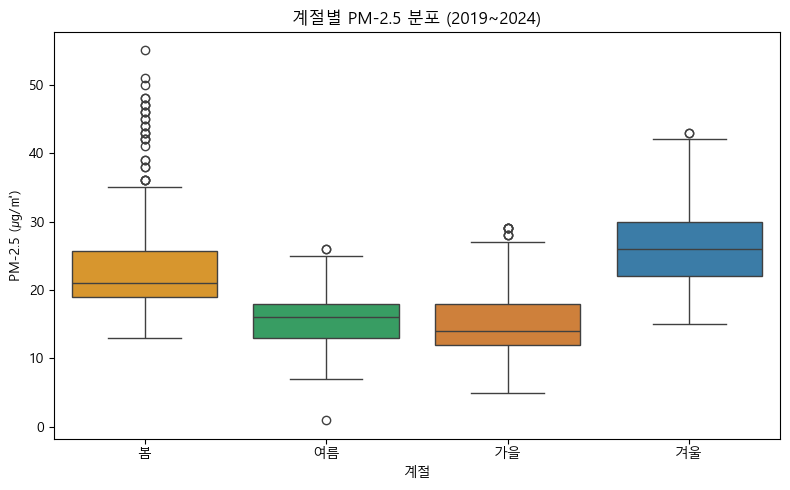

In [8]:
# 계절별 박스플롯
season_order = ['봄', '여름', '가을', '겨울']
season_data = df_pm25_long[df_pm25_long['연도'].between(2019, 2024)]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=season_data,
    x='계절', y='PM25',
    order=season_order,
    palette=['#f39c12', '#27ae60', '#e67e22', '#2980b9'],
    ax=ax
)
ax.set_xlabel('계절')
ax.set_ylabel('PM-2.5 (㎍/㎥)')
ax.set_title('계절별 PM-2.5 분포 (2019~2024)')
plt.tight_layout()
plt.savefig('eda_season_box.png', dpi=150)
plt.show()

## 3. 가설검정

### H1: 녹지 면적이 많은 자치구는 PM-2.5가 낮다

In [9]:
# 자치구 평균 기준 녹지면적 중앙값으로 고녹지/저녹지 그룹 분류
gu_summary = (
    df_merged.groupby('자치구')[['PM25_연평균', '녹지면적_km2', '공원율']]
    .mean()
    .reset_index()
)

median_green = gu_summary['녹지면적_km2'].median()
gu_summary['녹지그룹'] = gu_summary['녹지면적_km2'].apply(
    lambda x: '고녹지' if x >= median_green else '저녹지'
)

high_green = gu_summary[gu_summary['녹지그룹'] == '고녹지']['PM25_연평균']
low_green  = gu_summary[gu_summary['녹지그룹'] == '저녹지']['PM25_연평균']

print(f'녹지면적 중앙값: {median_green:.3f} km²')
print(f'고녹지 그룹 ({len(high_green)}개구) PM-2.5 평균: {high_green.mean():.2f} ㎍/㎥')
print(f'저녹지 그룹 ({len(low_green)}개구) PM-2.5 평균: {low_green.mean():.2f} ㎍/㎥')

# 정규성 검정 (Shapiro-Wilk)
_, p_high = stats.shapiro(high_green)
_, p_low  = stats.shapiro(low_green)
print(f'\n정규성 검정 (Shapiro-Wilk):')
print(f'  고녹지: p = {p_high:.4f} {"→ 정규분포" if p_high > 0.05 else "→ 비정규"}')
print(f'  저녹지: p = {p_low:.4f} {"→ 정규분포" if p_low > 0.05 else "→ 비정규"}')

녹지면적 중앙값: 0.418 km²
고녹지 그룹 (13개구) PM-2.5 평균: 20.48 ㎍/㎥
저녹지 그룹 (12개구) PM-2.5 평균: 19.96 ㎍/㎥

정규성 검정 (Shapiro-Wilk):
  고녹지: p = 0.7146 → 정규분포
  저녹지: p = 0.7449 → 정규분포


등분산 검정 (Levene): p = 0.1533 → 등분산

[H1] 독립표본 t-test 결과
  t = 1.8939, p = 0.0709
  → 귀무가설 기각 불가 (차이 없음)


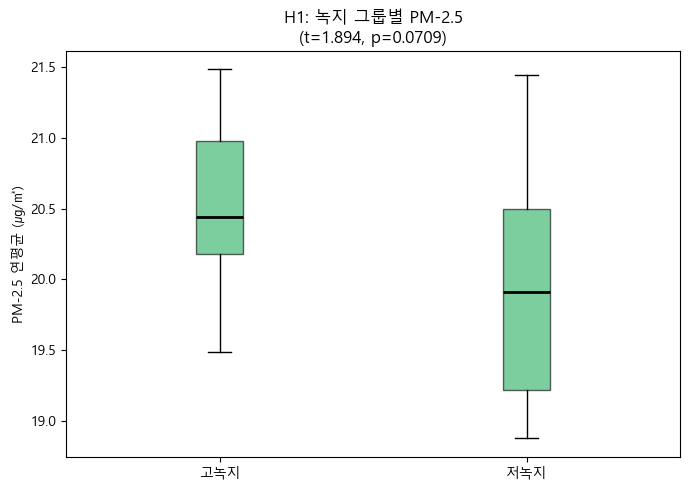

In [10]:
# 등분산 검정 (Levene)
_, p_levene = stats.levene(high_green, low_green)
print(f'등분산 검정 (Levene): p = {p_levene:.4f} {"→ 등분산" if p_levene > 0.05 else "→ 이분산"}')

equal_var = p_levene > 0.05

# 독립표본 t-test
t_stat, p_val = stats.ttest_ind(high_green, low_green, equal_var=equal_var)

print(f'\n[H1] 독립표본 t-test 결과')
print(f'  t = {t_stat:.4f}, p = {p_val:.4f}')
print(f'  → {"유의수준 0.05에서 귀무가설 기각 (차이 있음)" if p_val < 0.05 else "귀무가설 기각 불가 (차이 없음)"}')

# 시각화
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([high_green, low_green], labels=['고녹지', '저녹지'],
           patch_artist=True,
           boxprops=dict(facecolor='#27ae60', alpha=0.6),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('PM-2.5 연평균 (㎍/㎥)')
ax.set_title(f'H1: 녹지 그룹별 PM-2.5\n(t={t_stat:.3f}, p={p_val:.4f})')
plt.tight_layout()
plt.savefig('h1_ttest.png', dpi=150)
plt.show()

### H2: 계절에 따라 PM-2.5 평균에 유의한 차이가 있다

In [11]:
season_data_19_24 = df_pm25_long[df_pm25_long['연도'].between(2019, 2024)]

spring = season_data_19_24[season_data_19_24['계절'] == '봄']['PM25']
summer = season_data_19_24[season_data_19_24['계절'] == '여름']['PM25']
autumn = season_data_19_24[season_data_19_24['계절'] == '가을']['PM25']
winter = season_data_19_24[season_data_19_24['계절'] == '겨울']['PM25']

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(spring, summer, autumn, winter)

print('[H2] One-way ANOVA 결과')
print(f'  F = {f_stat:.4f}, p = {p_anova:.6f}')
print(f'  → {"유의수준 0.05에서 귀무가설 기각 (계절 간 차이 있음)" if p_anova < 0.05 else "차이 없음"}')
print()
print('계절별 평균:')
for s, d in zip(['봄','여름','가을','겨울'], [spring, summer, autumn, winter]):
    print(f'  {s}: {d.mean():.2f} ㎍/㎥ (n={len(d)})')

[H2] One-way ANOVA 결과
  F = 445.4110, p = 0.000000
  → 유의수준 0.05에서 귀무가설 기각 (계절 간 차이 있음)

계절별 평균:
  봄: 23.24 ㎍/㎥ (n=450)
  여름: 15.68 ㎍/㎥ (n=449)
  가을: 15.36 ㎍/㎥ (n=438)
  겨울: 26.42 ㎍/㎥ (n=448)


[Tukey HSD 사후검정]
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    가을     겨울  11.0611    0.0  10.1048 12.0175   True
    가을      봄   7.8815    0.0   6.9262  8.8368   True
    가을     여름   0.3208 0.8239   -0.635  1.2766  False
    겨울      봄  -3.1797    0.0  -4.1295 -2.2298   True
    겨울     여름 -10.7404    0.0 -11.6908   -9.79   True
     봄     여름  -7.5607    0.0    -8.51 -6.6114   True
-----------------------------------------------------


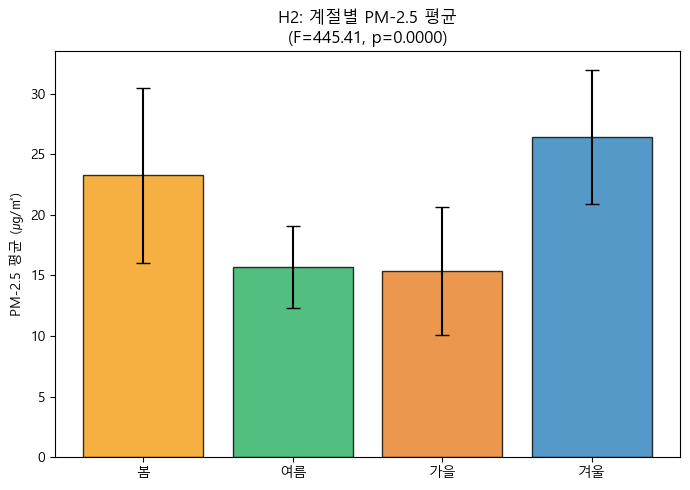

In [12]:
# 사후 검정 (Tukey HSD) — ANOVA 유의할 경우 어떤 계절 간 차이인지 파악
if p_anova < 0.05:
    tukey_data = season_data_19_24[['PM25', '계절']].dropna()
    tukey = pairwise_tukeyhsd(endog=tukey_data['PM25'], groups=tukey_data['계절'], alpha=0.05)
    print('[Tukey HSD 사후검정]')
    print(tukey.summary())

# 계절별 평균 막대 그래프
season_means = {
    s: d.mean() for s, d in
    zip(['봄', '여름', '가을', '겨울'], [spring, summer, autumn, winter])
}
season_stds = {
    s: d.std() for s, d in
    zip(['봄', '여름', '가을', '겨울'], [spring, summer, autumn, winter])
}

fig, ax = plt.subplots(figsize=(7, 5))
colors_s = ['#f39c12', '#27ae60', '#e67e22', '#2980b9']
ax.bar(season_means.keys(), season_means.values(),
       yerr=season_stds.values(), color=colors_s, alpha=0.8,
       capsize=5, edgecolor='black')
ax.set_ylabel('PM-2.5 평균 (㎍/㎥)')
ax.set_title(f'H2: 계절별 PM-2.5 평균\n(F={f_stat:.2f}, p={p_anova:.4f})')
plt.tight_layout()
plt.savefig('h2_anova.png', dpi=150)
plt.show()

### H3: 2019~2024년 PM-2.5가 유의하게 감소했다

[H3] 추세 회귀 검정 결과
  기울기(slope): -1.2060 ㎍/㎥ per year
  R² = 0.7359
  p = 0.0289
  → 유의수준 0.05에서 유의한 감소 추세


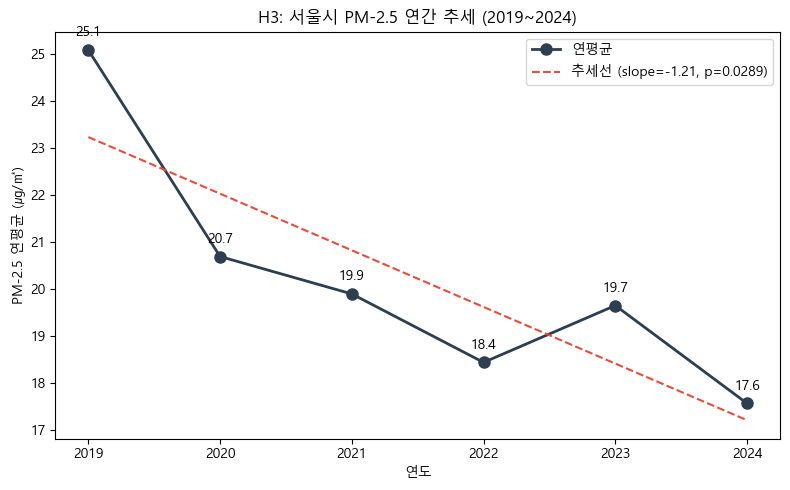

In [13]:
# 연간 평균 PM-2.5 (서울 전체)
annual_pm25 = (
    df_pm25_long[df_pm25_long['연도'].between(2019, 2024)]
    .groupby('연도')['PM25']
    .mean()
    .reset_index()
)

years = annual_pm25['연도'].values
pm25_vals = annual_pm25['PM25'].values

# 선형 회귀 (연도 ~ PM-2.5)
slope, intercept, r_value, p_trend, std_err = stats.linregress(years, pm25_vals)

print('[H3] 추세 회귀 검정 결과')
print(f'  기울기(slope): {slope:.4f} ㎍/㎥ per year')
print(f'  R² = {r_value**2:.4f}')
print(f'  p = {p_trend:.4f}')
print(f'  → {"유의수준 0.05에서 유의한 감소 추세" if (p_trend < 0.05 and slope < 0) else "유의한 추세 없음"}')

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, pm25_vals, 'o-', color='#2c3e50', linewidth=2, markersize=8, label='연평균')

fit_line = slope * years + intercept
ax.plot(years, fit_line, '--', color='#e74c3c', linewidth=1.5,
        label=f'추세선 (slope={slope:.2f}, p={p_trend:.4f})')

for yr, val in zip(years, pm25_vals):
    ax.annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)

ax.set_xlabel('연도')
ax.set_ylabel('PM-2.5 연평균 (㎍/㎥)')
ax.set_title('H3: 서울시 PM-2.5 연간 추세 (2019~2024)')
ax.legend()
ax.set_xticks(years)
plt.tight_layout()
plt.savefig('h3_trend.png', dpi=150)
plt.show()

## 4. 회귀분석: PM-2.5 ~ 녹지면적 + 공원율

In [14]:
import statsmodels.api as sm

reg_df = df_merged[['PM25_연평균', '녹지면적_km2', '공원율']].dropna()

X = reg_df[['녹지면적_km2', '공원율']]
X = sm.add_constant(X)
y = reg_df['PM25_연평균']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               PM25_연평균   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.5299
Date:                Fri, 24 Apr 2026   Prob (F-statistic):              0.590
Time:                        16:06:03   Log-Likelihood:                -362.32
No. Observations:                 150   AIC:                             730.6
Df Residuals:                     147   BIC:                             739.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.7242      0.691     30.000      0.0

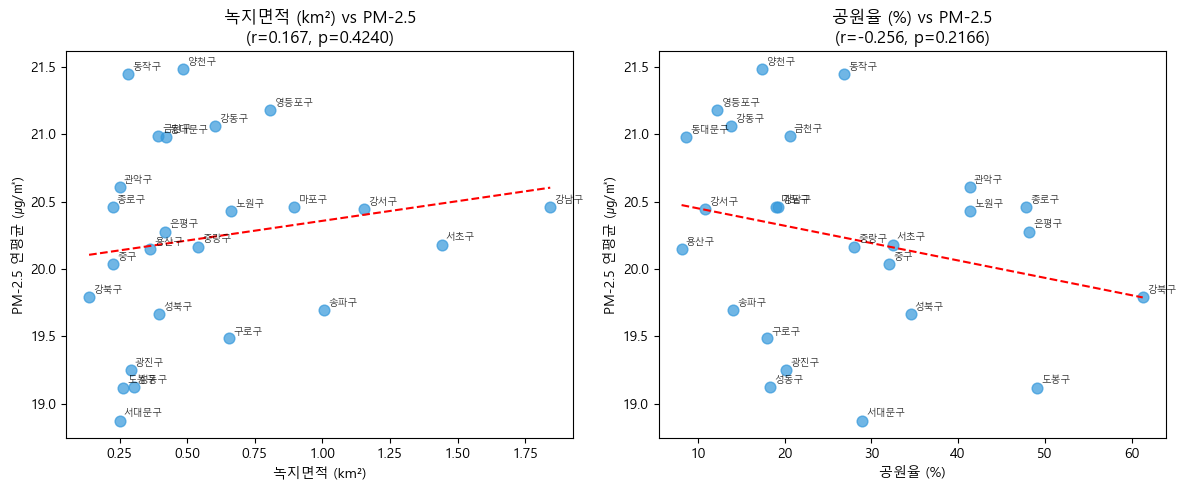

In [15]:
# 산점도: 녹지면적 vs PM-2.5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(
    axes,
    ['녹지면적_km2', '공원율'],
    ['녹지면적 (km²)', '공원율 (%)']
):
    x_data = df_merged.groupby('자치구')[col].mean()
    y_data = df_merged.groupby('자치구')['PM25_연평균'].mean()

    common_idx = x_data.index.intersection(y_data.index)
    x_vals = x_data[common_idx].values
    y_vals = y_data[common_idx].values

    ax.scatter(x_vals, y_vals, alpha=0.7, s=60, color='#3498db')

    # 회귀선
    slope_s, intercept_s, r_s, p_s, _ = stats.linregress(x_vals, y_vals)
    x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_range, slope_s * x_range + intercept_s, 'r--', linewidth=1.5)

    # 자치구 레이블
    for gu, x, y in zip(common_idx, x_vals, y_vals):
        ax.annotate(gu, (x, y), fontsize=7, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel(label)
    ax.set_ylabel('PM-2.5 연평균 (㎍/㎥)')
    ax.set_title(f'{label} vs PM-2.5\n(r={r_s:.3f}, p={p_s:.4f})')

plt.tight_layout()
plt.savefig('regression_scatter.png', dpi=150)
plt.show()

## 5. 결과 요약

In [16]:
print('=' * 60)
print('분석 결과 요약')
print('=' * 60)
print()
print(f'[H1] 녹지 그룹별 PM-2.5 차이')
print(f'  고녹지 평균: {high_green.mean():.2f} / 저녹지 평균: {low_green.mean():.2f}')
print(f'  t={t_stat:.3f}, p={p_val:.4f} → {"유의" if p_val < 0.05 else "비유의"}')
print()
print(f'[H2] 계절별 PM-2.5 차이')
for s, d in zip(['봄','여름','가을','겨울'], [spring, summer, autumn, winter]):
    print(f'  {s}: {d.mean():.2f}')
print(f'  F={f_stat:.3f}, p={p_anova:.6f} → {"유의" if p_anova < 0.05 else "비유의"}')
print()
print(f'[H3] 연간 감소 추세')
print(f'  slope={slope:.3f} ㎍/㎥/yr, R²={r_value**2:.3f}, p={p_trend:.4f}')
print(f'  → {"유의한 감소" if (p_trend < 0.05 and slope < 0) else "유의하지 않음"}')
print()
print(f'[회귀분석] PM-2.5 ~ 녹지면적 + 공원율')
print(f'  R² = {model.rsquared:.4f}')

분석 결과 요약

[H1] 녹지 그룹별 PM-2.5 차이
  고녹지 평균: 20.48 / 저녹지 평균: 19.96
  t=1.894, p=0.0709 → 비유의

[H2] 계절별 PM-2.5 차이
  봄: 23.24
  여름: 15.68
  가을: 15.36
  겨울: 26.42
  F=445.411, p=0.000000 → 유의

[H3] 연간 감소 추세
  slope=-1.206 ㎍/㎥/yr, R²=0.736, p=0.0289
  → 유의한 감소

[회귀분석] PM-2.5 ~ 녹지면적 + 공원율
  R² = 0.0072
